# 03 - Can one station closure spread across the railway?

**Demonstration (about three minutes).** Start with maximum-load failure at
alpha 0.2, move alpha to 0.525, then switch to dynamic routing. Finally choose
a station yourself and reveal its failure rounds on the map.

This notebook separates the external closure from **secondary overloads**.
It reads the committed P2.2 samples and P2.5 confidence intervals for statistical
plots. The controls run one small experiment through the production engine;
they do not regenerate the thousands of stored trials. The frozen graph is the
5 October 2026 [07:00, 09:00) Perth baseline from Notebook 01.

In [1]:
from pathlib import Path
import sys
import time
from functools import lru_cache

started = time.perf_counter()
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src/transperth/config.py').is_file())
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import HTML, Image, display
from io import BytesIO
from transperth.config import CascadeConfig
from transperth.cascade import simulate_cascade
from transperth.network import load_rail_graph
from transperth.notebook_support import verify_processed, read_result, network_map_html
from transperth.plotting import apply_style

manifest = verify_processed(ROOT)
rail = load_rail_graph()
apply_style()
def show_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
runs = read_result(ROOT, 'results/cascade/runs.csv', dtype={'target': str})
avalanche = read_result(ROOT, 'results/cascade/avalanche_samples.csv')
cascade_ci = read_result(ROOT, 'results/uncertainty/cascade_ci.csv')
avalanche_ci = read_result(ROOT, 'results/uncertainty/avalanche_ci.csv')
assert len(avalanche) == 16000
display(avalanche.groupby(['dynamic', 'alpha']).size().rename('random trigger observations').to_frame())

random trigger observations
dynamic alpha                             
False   0.10                          2000
        0.15                          2000
        0.20                          2000
        0.30                          2000
True    0.10                          2000
        0.15                          2000
        0.20                          2000
        0.30                          2000

## Capacity and the two update rules

Motter and Lai's [cascade model](https://doi.org/10.1103/PhysRevE.66.065102)
assigns capacity from intact shortest-path load and checks overload after
rerouting. We use that capacity idea and compare dynamic rerouting with a
separate local redistribution scenario. Static redistribution is our modelling
extension; it is not the original shortest-path recomputation rule.

Initial load is unnormalised betweenness on the intact railway:

$$
L_i^0=\sum_{\{s,t\}\subset V\setminus\{i\}}\frac{\sigma_{st}(i)}{\sigma_{st}},\qquad C_i=(1+\alpha)L_i^0.
$$

Each unordered endpoint pair contributes through intermediate stations.
Unreachable pairs contribute nothing. Capacities stay fixed after removal.
Alpha is spare capacity relative to this proxy, **not a probability of failure**.

The chosen trigger closes before round 1. A round collects all current overloads,
then removes them simultaneously:

$$
F_r=\{i\in V_r:L_i(r)>C_i+10^{-12}\}.
$$

In **static mode**, a failed station sends its carried load to neighbours that
survive the same round. The weights below allocate the whole amount; if all
recipient capacities are zero, capacity weighting falls back to equal shares.
A failed station with no survivor neighbours removes its carried load from the
system. This lost amount is tracked rather than forwarded to a nonexistent path.

$$
w_{ij}=\frac{1}{|N_i^{\mathrm{surv}}|}\quad\text{(equal)},\qquad
w_{ij}=\frac{C_j}{\sum_{k\in N_i^{\mathrm{surv}}}C_k}\quad\text{(capacity)}.
$$

In **dynamic mode**, shortest-path load is recomputed on the remaining graph
after each removal. Equal/capacity redistribution has no role. On a tree,
removal cannot create another rail path; surviving betweenness cannot increase.
Consequently, containment here does not establish robustness of a railway with
loops or a bus layer. Missing paths can still leave travel unserved.

The definitions and supported alternative load proxies are in
[docs/model.md, sections 2-4](../docs/model.md).

In [2]:
# A visible regression at the resolution used in the tolerance experiment.
below = simulate_cascade(rail, CascadeConfig(alpha=0.5, trigger='load'))
contained = simulate_cascade(rail, CascadeConfig(alpha=0.525, trigger='load'))
dynamic = simulate_cascade(rail, CascadeConfig(alpha=0.2, trigger='load', dynamic=True))
assert below.n_failed > 1 and contained.n_failed == 1
assert dynamic.n_failed == 1 and dynamic.rounds == 0
display(pd.DataFrame([{'scenario': name, 'initial_station': result.initial_failed[0],
                       'name': rail.nodes[result.initial_failed[0]]['name'],
                       'failed_including_trigger': result.n_failed,
                       'secondary_failures': sum(result.avalanche_sizes),
                       'secondary_rounds': result.rounds, 'GCC / 86': result.gcc_fraction}
                      for name, result in [('static, alpha=0.5', below),
                                           ('static, alpha=0.525', contained),
                                           ('dynamic, alpha=0.2', dynamic)]]))

,scenario,initial_station,name,failed_including_trigger,secondary_failures,secondary_rounds,GCC / 86
0,"static, alpha=0.5",72,Claisebrook Stn,86,85,31,0.000000
1,"static, alpha=0.525",72,Claisebrook Stn,1,0,0,0.546512
2,"dynamic, alpha=0.2",72,Claisebrook Stn,1,0,0,0.546512


## Tolerance and redistribution-rule comparison

Solid targeted curves are deterministic. The random curves use **300 whole
trigger trials** per alpha/rule; shaded intervals are pointwise 95% percentile
bootstrap intervals from P2.5, with 2,000 resamples. All failed fractions include
the initial closure and use the intact 86 stations as the denominator. A sampled
containment threshold is grid dependent; it is not a thermodynamic critical point.

Sources: [run_cascades.py](../scripts/run_cascades.py),
[run_uncertainty.py](../scripts/run_uncertainty.py),
[cascade_ci.csv](../results/uncertainty/cascade_ci.csv).

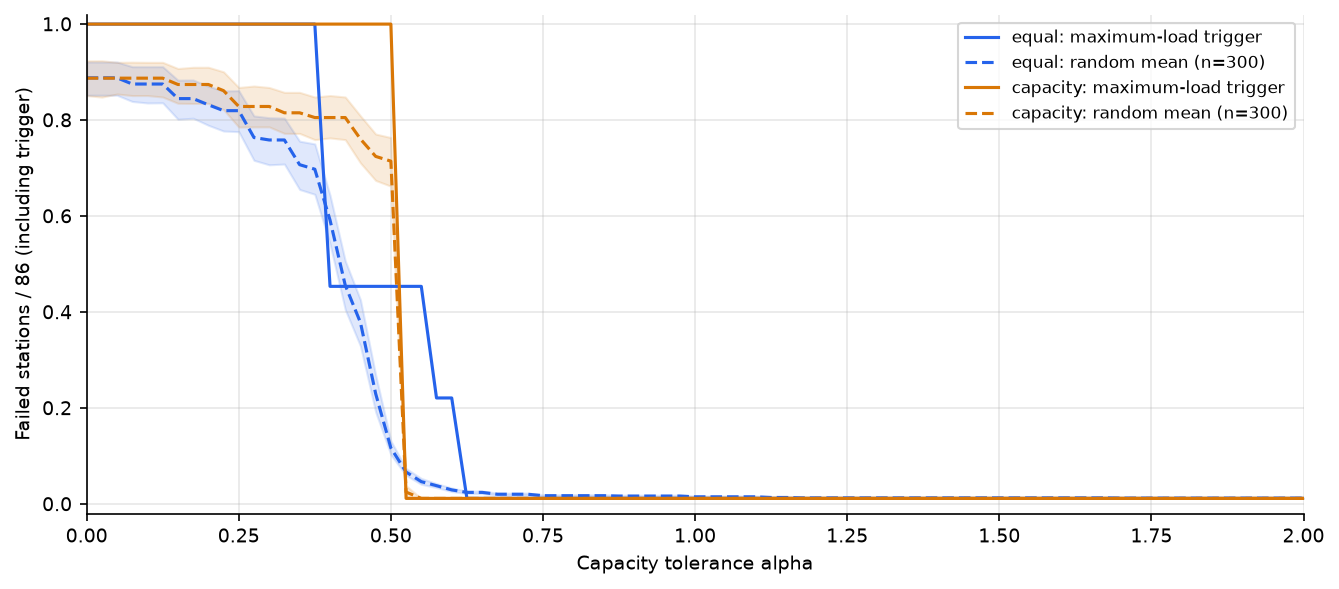

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for colour, rule in zip(['#2563eb', '#d97706'], ['equal', 'capacity']):
    deterministic = runs[(runs.rule == rule) & (runs.trigger == 'load')].sort_values('alpha')
    ax.plot(deterministic.alpha, deterministic.failed_fraction, color=colour,
            label=f'{rule}: maximum-load trigger')
    ci = cascade_ci[(cascade_ci.rule == rule) & (cascade_ci.metric == 'failed_fraction')].sort_values('alpha')
    ax.plot(ci.alpha, ci['mean'], '--', color=colour, label=f'{rule}: random mean (n=300)')
    ax.fill_between(ci.alpha, ci.low, ci.high, color=colour, alpha=0.14)
ax.set(xlabel='Capacity tolerance alpha', ylabel='Failed stations / 86 (including trigger)',
       ylim=(-0.02, 1.02), xlim=(0, 2))
ax.legend(fontsize=8)
fig.tight_layout()
show_figure(fig)
plt.close(fig)

## Avalanche size and duration: count the secondary failures

For one trigger experiment, total secondary size and duration are:

$$
S=\sum_{r=1}^{D}|F_r|,\qquad D=\text{number of secondary failure rounds}.
$$

These are distinct from per-round avalanche sizes. Duration counts algorithmic
updates, **not minutes**. Each distribution below uses 2,000 independently
sampled random triggers at a fixed alpha and update mode. Repeated station draws
are valid sampling with replacement; their deterministic outcomes may coincide.
Zeros remain in the distributions. We neither pool alphas nor treat rounds of
one cascade as independent observations.

Source: [avalanche_samples.csv](../results/cascade/avalanche_samples.csv),
generated by [run_cascades.py](../scripts/run_cascades.py).

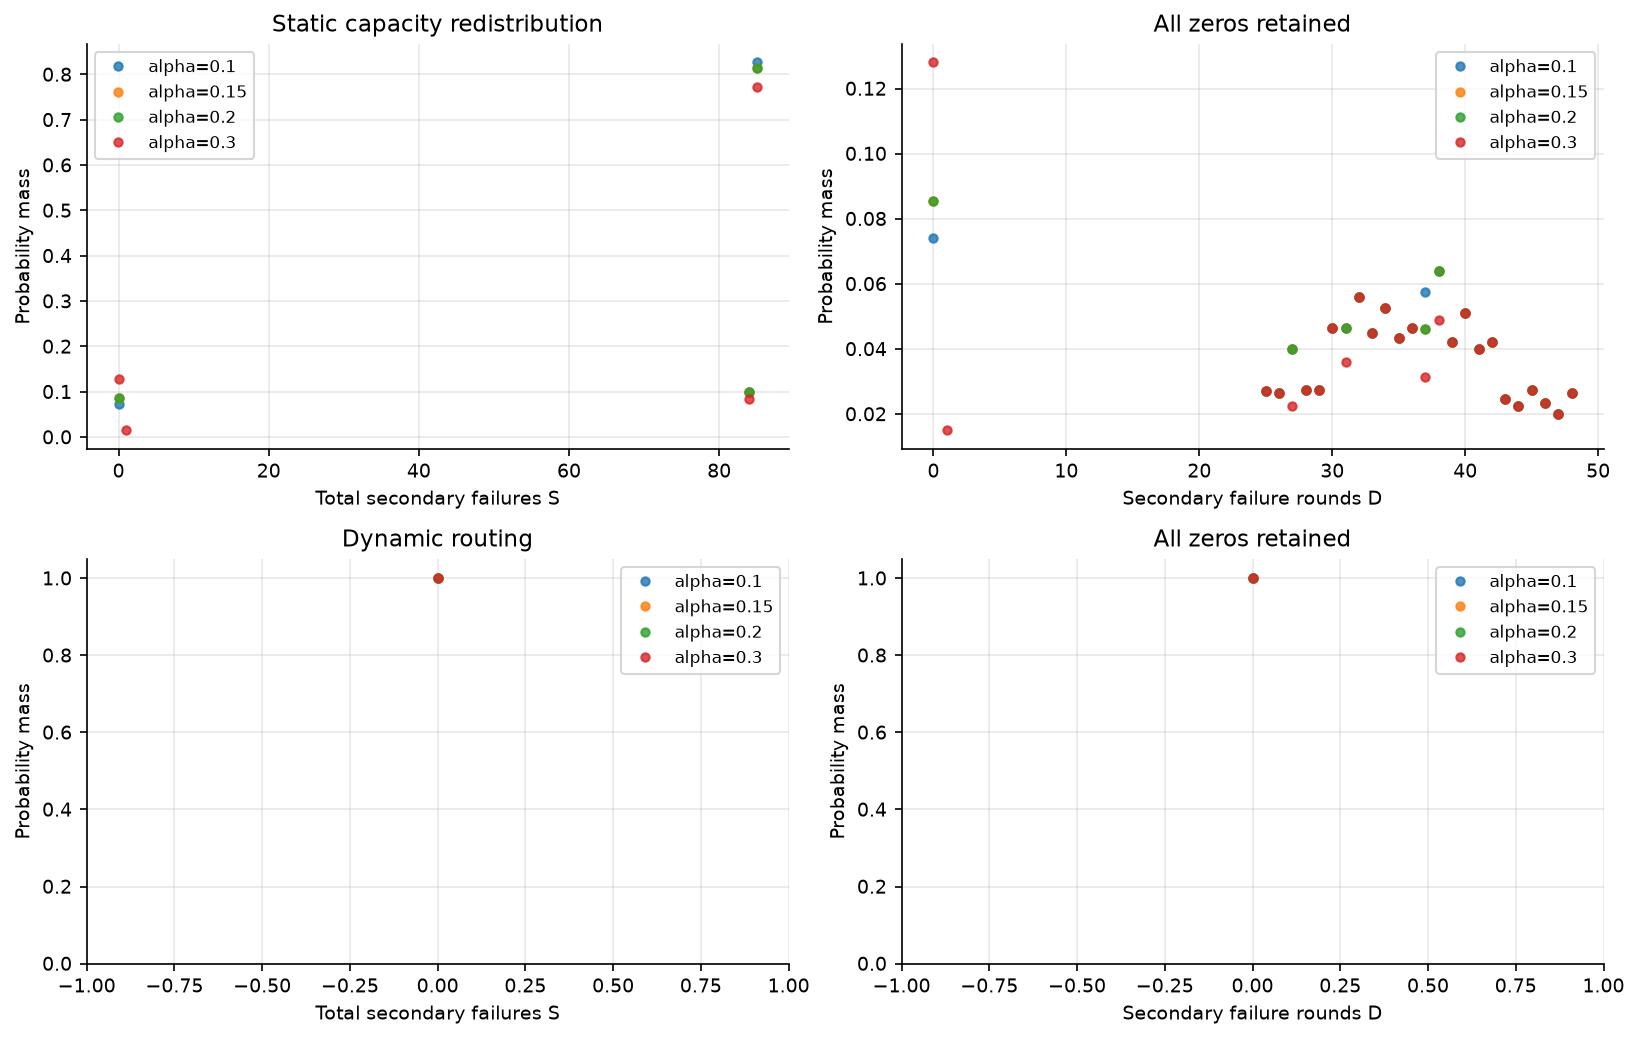

,dynamic,alpha,metric,n,mean,low,high
0,False,0.10,post_trigger_size,2000,78.610,77.594,79.616
1,False,0.10,rounds,2000,33.322,32.872,33.808
4,False,0.15,post_trigger_size,2000,77.633,76.566,78.648
5,False,0.15,rounds,2000,32.896,32.371,33.402
8,False,0.20,post_trigger_size,2000,77.633,76.620,78.654
9,False,0.20,rounds,2000,32.896,32.380,33.387
12,False,0.30,post_trigger_size,2000,72.776,71.457,74.004
13,False,0.30,rounds,2000,31.007,30.378,31.607
16,True,0.10,post_trigger_size,2000,0.000,0.000,0.000
17,True,0.10,rounds,2000,0.000,0.000,0.000


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for row, dynamic_mode in enumerate([False, True]):
    for alpha, group in avalanche[avalanche.dynamic == dynamic_mode].groupby('alpha'):
        for col, metric in enumerate(['post_trigger_size', 'rounds']):
            counts = group[metric].value_counts().sort_index()
            axes[row, col].plot(counts.index, counts.values / len(group), 'o',
                                label=f'alpha={alpha:g}', alpha=0.8, markersize=4)
    axes[row, 0].set(xlabel='Total secondary failures S', ylabel='Probability mass',
                     title='Dynamic routing' if dynamic_mode else 'Static capacity redistribution')
    axes[row, 1].set(xlabel='Secondary failure rounds D', ylabel='Probability mass',
                     title='All zeros retained')
    for ax in axes[row]:
        ax.legend(fontsize=8)
        if dynamic_mode:
            ax.set_ylim(0, 1.05)
            ax.set_xlim(-1, 1)
fig.tight_layout()
show_figure(fig)
plt.close(fig)
display(avalanche_ci[avalanche_ci.metric.isin(['post_trigger_size', 'rounds'])]
        [['dynamic', 'alpha', 'metric', 'n', 'mean', 'low', 'high']].round(3))

These finite distributions do **not support a power-law avalanche claim**.
Static alpha 0.1-0.2 has only two distinct positive sizes (84 and 85), below the
tail eligibility requirement. At alpha 0.3 the bounded decreasing power-law
hypothesis is rejected (p about 0.002; exponent at its lower bound). Dynamic
betweenness has only zero secondary failures. A straight-looking log-log plot
would not resolve these problems. See [P2.5 tail diagnostics](../docs/uncertainty.md).

## Choose a trigger and inspect one cascade

Controls run the **unweighted betweenness** scenario. Choose maximum load,
maximum degree, a seeded random station, or an explicit station. The explicit
station overrides other trigger choices only when "Chosen station" is selected.
For dynamic routing the redistribution dropdown is disabled because it is unused.

The map retains intact corridor geometry for orientation. Reveal rounds with the
last slider: blue stations have not failed by the displayed round. The initial
closure is red; secondary stations show their failure-round colours. The summary
always describes the final stable result. The lower plot counts the trigger
separately from secondary failures.

In [5]:
@lru_cache(maxsize=256)
def one_run(alpha, trigger, target, rule, dynamic, seed):
    return simulate_cascade(rail, CascadeConfig(alpha=alpha, trigger=trigger,
                            target=target, rule=rule, dynamic=dynamic, seed=seed))

def show_cascade(alpha, trigger, station, rule, dynamic, seed, reveal_round):
    mode = 'load' if trigger == 'chosen' else trigger
    target = station if trigger == 'chosen' else None
    result = one_run(alpha, mode, target, rule, dynamic, seed)
    rounds = {n: 0 for n in result.initial_failed}
    cursor = result.n_initial_failed
    for r, size in enumerate(result.avalanche_sizes, 1):
        rounds.update({n: r for n in result.failed[cursor:cursor + size]})
        cursor += size
    assert cursor == result.n_failed
    shown = min(reveal_round, result.rounds)
    display(pd.DataFrame([{'trigger_station': rail.nodes[result.initial_failed[0]]['name'],
                           'alpha': alpha, 'mode': 'dynamic routing' if dynamic else f'static {rule}',
                           'final_failed': result.n_failed, 'secondary_size': sum(result.avalanche_sizes),
                           'secondary_rounds': result.rounds, 'final_GCC / 86': result.gcc_fraction}]))
    if not dynamic:
        assert np.isclose(result.initial_total_load, result.remaining_load + result.lost_load)
        print(f'Load accounting: {result.initial_total_load:g} initial = '
              f'{result.remaining_load:g} remaining + {result.lost_load:g} lost')
    display(HTML(network_map_html(rail,
            failed_rounds={n: r for n, r in rounds.items() if r <= shown},
            title=f'{rail.nodes[result.initial_failed[0]]["name"]}: through round {shown} of {result.rounds}')))
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.bar(range(result.rounds + 1), [result.n_initial_failed, *result.avalanche_sizes], color='#2563eb')
    ax.patches[0].set_facecolor('#dc2626')
    ax.set(xlabel='Round (0 = external trigger)', ylabel='New failed stations',
           title='Update rounds are not elapsed travel time')
    show_figure(fig)
    plt.close(fig)

alpha_control = widgets.FloatSlider(value=0.2, min=0, max=2, step=0.025,
                                     description='Alpha:', continuous_update=False, readout_format='.3f')
trigger_control = widgets.Dropdown(options=[('Maximum load', 'load'), ('Maximum degree', 'degree'),
                                            ('Random station', 'random'), ('Chosen station', 'chosen')],
                                  description='Trigger:')
station_control = widgets.Dropdown(options=sorted([(d['name'] + ' (' + n + ')', n)
                                                   for n, d in rail.nodes(data=True)]),
                                  value='56', description='Station:', disabled=True,
                                  layout=widgets.Layout(width='420px'))
rule_control = widgets.Dropdown(options=['capacity', 'equal'], description='Rule:')
dynamic_control = widgets.Checkbox(value=False, description='Dynamic shortest-path rerouting')
seed_control = widgets.BoundedIntText(value=0, min=0, max=1000000, description='Seed:', disabled=True)
round_control = widgets.IntSlider(value=85, min=0, max=85, description='Show round:', continuous_update=False)
def update_controls(change=None):
    station_control.disabled = trigger_control.value != 'chosen'
    seed_control.disabled = trigger_control.value != 'random'
    rule_control.disabled = dynamic_control.value
trigger_control.observe(update_controls, names='value')
dynamic_control.observe(update_controls, names='value')
controls = {'alpha': alpha_control, 'trigger': trigger_control, 'station': station_control,
            'rule': rule_control, 'dynamic': dynamic_control, 'seed': seed_control,
            'reveal_round': round_control}
output = widgets.interactive_output(show_cascade, controls)
display(widgets.VBox([alpha_control, widgets.HBox([trigger_control, rule_control]),
                      station_control, dynamic_control, seed_control, round_control]), output)
print(f'Notebook computation: {time.perf_counter() - started:.2f} seconds')

Output()

Notebook computation: 1.47 seconds


## Interpretation and handoff

Containment of overload is not recovery of connectivity. Dynamic routing on
this tree drops load when pairs become unreachable, while local static
redistribution keeps forwarding a proxy load through surviving neighbours.
The sharp contrast therefore exposes a modelling assumption, not a measured
prediction that Perth passengers would keep travelling after losing their route.

The 95% intervals quantify random-trigger sampling error conditional on this
graph and proxy; they exclude uncertainty in passenger demand and the service
date. Notebook 04 adds bus paths, where restored reachability can raise load
on some rail facilities and reverse the simple tree argument.

Reproduce with `make notebooks` or `jupyter nbconvert --to notebook --execute
--inplace notebooks/03_cascades.ipynb`. Use a trusted notebook and a live
JupyterLab kernel for controls. The saved statistical figures remain readable
without a running kernel. Underlying experiment design: [docs/cascade_experiments.md](../docs/cascade_experiments.md).